# Top-NMF: Example 1

# Import Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import cv2
from PIL import Image, ImageDraw, ImageFont
from sklearn.decomposition._nmf import _initialize_nmf
from tqdm.notebook import tqdm

from TopNMF import *
from cubical_complex import *

device = 'cpu'

# Download font for Hangul generation
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    !wget -q -O NanumGothicCoding-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    print("Font Downloaded.")

2025-12-08 04:22:11.712768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765135331.723688  128374 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765135331.727094  128374 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 04:22:11.738584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Generate & Preprocess Hangul Characters

In [2]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """
    Generate images for the characters {가, 다, 라, 갸, 댜, 랴}
    using the NanumGothic font located in the same folder.
    The generated images will be saved in the Data/hangul-images directory.
    """

    
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()
    output_dir = os.path.join(base_dir, "Data")

    # Character set
    labels = ['가','다','라','갸','댜','랴']

    # Load the font
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)

    # Create output folder
    image_dir = os.path.join(output_dir, 'hangul-images')
    os.makedirs(image_dir, exist_ok=True)

    W, H = image_size
    total_count = 0

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)

        # Center text
        try:
            bbox = draw.textbbox((0, 0), ch, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except Exception:
            w, h = draw.textsize(ch, font=font)

        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)

        total_count += 1
        fname = f"{total_count:01d}.jpeg"
        img.save(os.path.join(image_dir, fname), 'JPEG')

    print(f"✅ Generated {total_count} images. Saved to: {image_dir}")

In [3]:
generate_hangul_images(font_size=48)

✅ Generated 6 images. Saved to: /home/keunsu/Top-NMF_temporal/Data/hangul-images


In [4]:
# Set image file paths
image_files = [f'./Data/hangul-images/{i}.jpeg' for i in range(1,7)]

# List to store image arrays
images = []

# Read each image file and convert to a NumPy grayscale array
for file in image_files:
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
    if img is not None:  # Verify the image loaded correctly
        images.append(img)

# Convert the list to a NumPy array
images_array = np.array(images)

# Print the array shape
print(images_array.shape)

binary_image_array = []

for i in range(images_array.shape[0]):
    _, binary_image = cv2.threshold(images_array[i], 127, 255, cv2.THRESH_BINARY)
    binary_image_array.append(binary_image)

binary_image_array = np.array(binary_image_array)

(6, 64, 64)


(6, 64, 64) (6, 5) (5, 4096)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

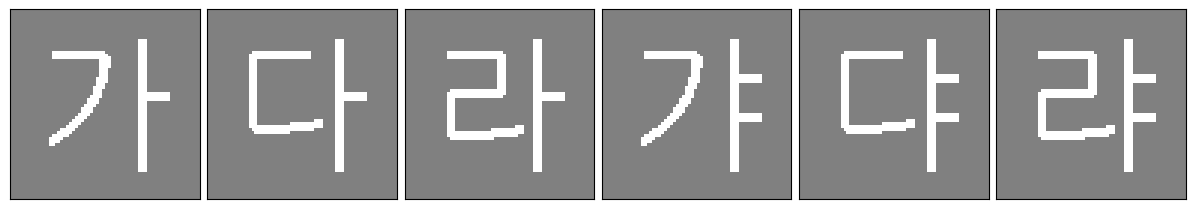

In [5]:
X = binary_image_array/255
n_components = 5 # number of basis vectors

### Start
n_samples = X.shape[0] # each row represents a sample
data_dims = X.shape[1:]
n_features = X[0].size

# Initialize with random nonnegative values
W = np.abs(np.random.normal(size=(n_samples, n_components)))
V = np.abs(np.random.normal(size=(n_components, n_features))) # each row represents a basis vector

W,V = _initialize_nmf(X.copy().reshape(X.shape[0], -1), n_components=n_components, init='nndsvda', random_state=42)

print(X.shape,W.shape,V.shape)

n_row, n_col = 1, 6 # display

plot_gallery(X,n_row=n_row, n_col = n_col)

# Run Top-NMF

  0%|          | 0/30000 [00:00<?, ?it/s]

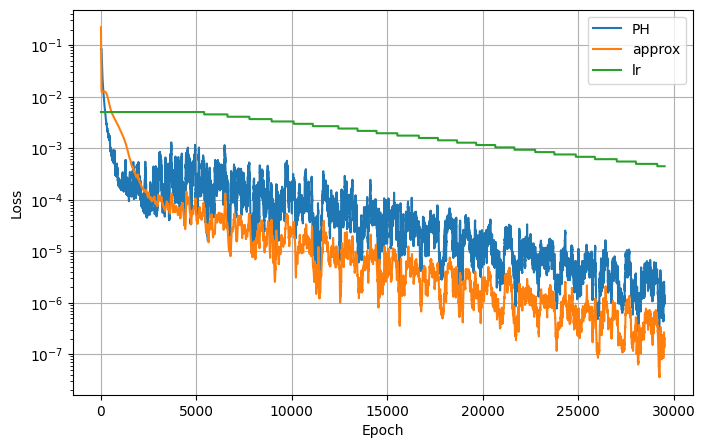

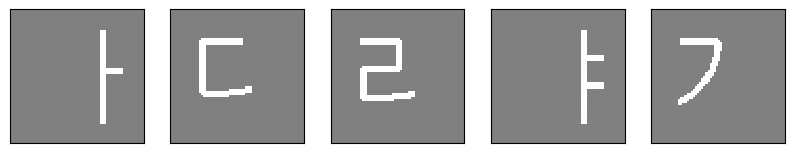

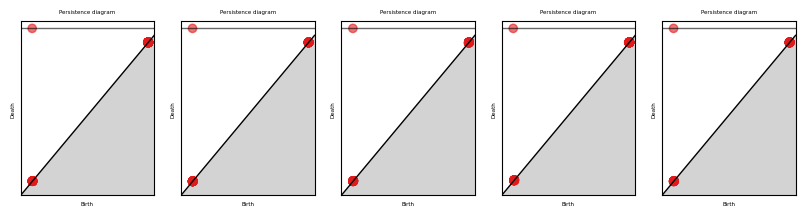

/home/keunsu/.local/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:112: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


In [6]:
# fit
lr = 0.005 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]

gd_iter = 1 # gradient descent update per iteration
mu_iter = 0 # multiplicative update per iteration
W_iter = 1 # W update per multiplicative update iteration
start_epoch_sparsify =0 # from this epoch, start sprase_opt
start_epoch_topological=0 # from this epoch, start loss_PH optimisation
show_plots = ["loss","basis","PH"] # ["loss","basis","PH"]

lambda_top = 0.5 # 0.5 # top-NMF   # around 0.001
weight_decay = 0.1

init_optimizer = True
normalise = False

## filtration
cpx = CubicalComplex(superlevel=superlevel,dim=len(data_dims),mode=PHmode)


##
n_row, n_col = 1 , 5 # display
n_iterations = 30000
PH_dims = [0,1] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 30000 # early stopping
disp_interval = 10

loss_fn = torch.nn.MSELoss() # approximation error
# loss_fn = torch.nn.HuberLoss() # approximation error



##
X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)
Vns = []
if normalise:
    with torch.no_grad():
        V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)


## initialise optimiser
if init_optimizer:
    opt = optim.AdamW([W, V], lr=lr, weight_decay=weight_decay) # SGD, Adam, AdamW(weight decay for sparsity), or NAdam?
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=1000)



## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
losses = {"PH":[], "approx":[], "lr":[]}


# prepare figures
if "loss" in show_plots:
    fig_L,axs_L = plt.subplots(1,1,figsize=(8,5))
    disp_L = display(fig_L,display_id=True)
if "basis" in show_plots:
    fig_V,axs_V = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_V = display(fig_V,display_id=True)
if "PH" in show_plots:
    fig_P,axs_P = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row), squeeze=False)
    disp_P = display(fig_P,display_id=True)

## main iteration
for epoch in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None or epoch<start_epoch_sparsify:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_V(X, W, V, target_L1) # update "V" with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of rows of V
        loss_PH=torch.tensor(0., device=device)
        if target_PH is None:
            loss_PH -= n_components
      
        for j in range(n_components):
            v=V[j]
            # PH sparsity
            if lambda_top>=0:
                diags = cpx(v.reshape(data_dims))
                if target_PH is None:
                    # PH sparsity
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)                    
                    l1sq = pers1.sum()**2
                    l2sq = pers1.pow(2).sum()
                    loss_PH += (l1sq/(l2sq+epsilon))
                else:
                    # target PH
                    if epoch>=start_epoch_topological:
                        for dim in PH_dims:
                            if dim==0:
                                remove_longest_D1=True
                            else:
                                remove_longest_D1=False    
                            loss_PH += pers_loss(diags[dim].diagram, target_PH[dim],remove_longest_D1=remove_longest_D1)
   

        loss_PH /= n_components
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = loss_apx + lambda_top * loss_PH
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step(loss)
        losses["PH"].append(loss_PH.item())
        losses["approx"].append(loss_apx.item())
        losses["lr"].append(scheduler.get_last_lr()[0])

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        W.clamp_(min=0)
        V.clamp_(min=0)
        if normalise:
            V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)

    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},approx: {loss_apx.item():.08f}')
    if epoch%disp_interval==0:
        Vns.append(V.detach().cpu().numpy().copy())
        #clear_output(wait=True)
        
        # for key in losses.keys():
        #     line[key].set_xdata(range(len(losses[key])))
        #     line[key].set_ydata(losses[key])
        if "loss" in show_plots:
            plot_loss(losses,ax=axs_L)
            disp_L.update(fig_L)
        if "basis" in show_plots:
            plot_gallery(Vns[-1].reshape(-1,*data_dims),title="basis",n_row=n_row, n_col = n_col, axs=axs_V)
            disp_V.update(fig_V)
        if "PH" in show_plots:
            plot_PD(Vns[-1].reshape(-1,*data_dims),n_row=n_row, n_col = n_col, axs=axs_P,PHmode = PHmode, superlevel=superlevel)
            disp_P.update(fig_P)
        #plt.show()
        #display(plt.gcf())
        disp_interval = int(1.2*disp_interval) # increase interval

    # early stopping
    current = loss_apx + lambda_top * loss_PH
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

# check norm
plt.close('all')

# Display Learned Basis Vectors (Top-NMF)

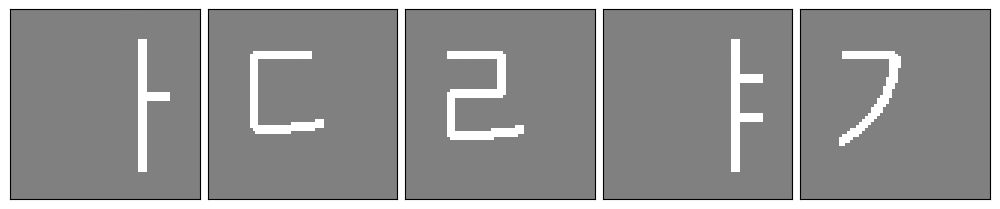

In [12]:
_ = plot_gallery(V.detach().numpy().reshape(-1,*data_dims),title="",n_row=1, n_col = 5)

# Quantitative Evaluation (IoU)

In [8]:
def compute_iou(pred_vector, true_mask, threshold_ratio=0.05):
    """
    Calculate Intersection over Union (IoU) between a predicted basis vector 
    and a binary ground truth mask.
    """
    pred_vector = pred_vector.reshape(true_mask.shape)
    # Convert continuous basis vector to binary mask using threshold
    threshold = threshold_ratio * np.max(pred_vector)
    pred_mask = (pred_vector > threshold).astype(int)
    
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def compute_jamo_iou(V, masks, threshold_ratio=0.05):
    """
    Find the best matching basis vector for each ground truth Jamo mask
    and compute the IoU score.
    """
    results = {}
    used_indices = set()
    
    for jamo, mask in masks.items():
        best_iou = -1.0
        best_index = -1
        
        # Greedy matching: find best basis for this mask
        for i in range(V.shape[0]):
            iou = compute_iou(V[i], mask, threshold_ratio)
            if iou > best_iou:
                best_iou = iou
                best_index = i
        
        results[jamo] = {"iou": best_iou, "basis_index": best_index}
    
    # Calculate Average IoU
    avg_iou = np.mean([info['iou'] for info in results.values()])
    return results, avg_iou

## Construct Ground Truth Masks

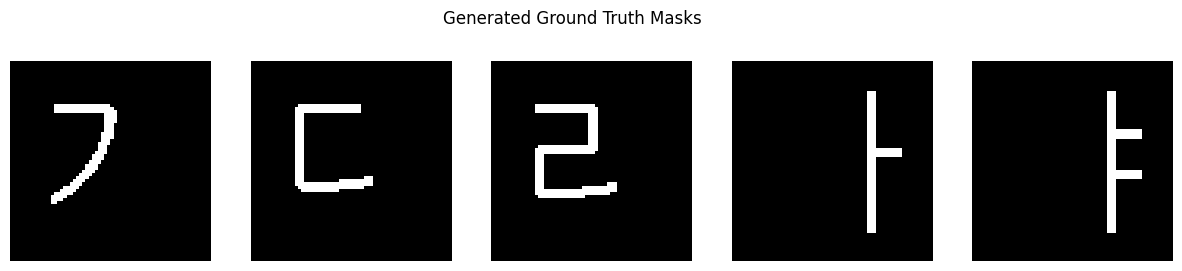

In [9]:
from scipy.ndimage import label

def extract_consonant_vowel_masks(image, threshold=0.5):
    """
    Splits a character image into consonant (left) and vowel (right) parts
    using connected component labeling and centroid coordinates.
    """
    binary = (image > threshold).astype(int)
    labeled, num_features = label(binary)
    
    consonant_mask = np.zeros_like(binary, dtype=int)
    vowel_mask = np.zeros_like(binary, dtype=int)
    mid_col = image.shape[1] / 2
    
    for comp_id in range(1, num_features + 1):
        comp = (labeled == comp_id)
        centroid_col = np.column_stack(np.where(comp))[:, 1].mean()
        
        if centroid_col < mid_col:
            consonant_mask[comp] = 1
        else:
            vowel_mask[comp] = 1
            
    return consonant_mask, vowel_mask

# 1. Configuration for Jamo Composition
# Indices: 0:가, 1:다, 2:라, 3:갸, 4:댜, 5:랴
idx_map = {
    'consonants': {'ㄱ': [0, 3], 'ㄷ': [1, 4], 'ㄹ': [2, 5]},
    'vowels':     {'ㅏ': [0, 1, 2], 'ㅑ': [3, 4, 5]}
}

# 2. Extract and Intersect Masks (to get the common shape)
ground_truth_masks = {}
X_np = X.detach().cpu().numpy() # Ensure numpy array

# Process Consonants
for jamo, indices in idx_map['consonants'].items():
    masks = [extract_consonant_vowel_masks(X_np[i].reshape(64,64))[0] for i in indices]
    ground_truth_masks[jamo] = np.logical_and.reduce(masks).astype(int).flatten()

# Process Vowels
for jamo, indices in idx_map['vowels'].items():
    masks = [extract_consonant_vowel_masks(X_np[i].reshape(64,64))[1] for i in indices]
    ground_truth_masks[jamo] = np.logical_and.reduce(masks).astype(int).flatten()

# 3. Visualize Ground Truths
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Generated Ground Truth Masks", y=1.0)
for ax, (jamo, mask) in zip(axes, ground_truth_masks.items()):
    ax.imshow(mask.reshape(64, 64), cmap='gray')
    ax.axis('off')
plt.show()

## Calculate Scores

In [10]:
# Compute Scores
# V should be the learned basis matrix from Top-NMF training
V_learned = V.detach().cpu().numpy()

results, avg_iou = compute_jamo_iou(V_learned, ground_truth_masks)

print("=== Evaluation Results (IoU) ===")
for jamo, info in results.items():
    print(f"Jamo {jamo}: IoU = {info['iou']:.4f} (Matched Basis #{info['basis_index']})")

print("-" * 30)
print(f"Average IoU: {avg_iou:.4f}")

=== Evaluation Results (IoU) ===
Jamo ㄱ: IoU = 1.0000 (Matched Basis #4)
Jamo ㄷ: IoU = 1.0000 (Matched Basis #1)
Jamo ㄹ: IoU = 1.0000 (Matched Basis #2)
Jamo ㅏ: IoU = 1.0000 (Matched Basis #0)
Jamo ㅑ: IoU = 1.0000 (Matched Basis #3)
------------------------------
Average IoU: 1.0000


# Compare with Standard NMF

=== Standard NMF Training (Baseline) ===
Visualizing Standard NMF Basis:

=== Standard NMF Evaluation Results ===
Jamo ㄱ: IoU = 0.5574 (Matched Basis #0)
Jamo ㄷ: IoU = 0.5970 (Matched Basis #1)
Jamo ㄹ: IoU = 0.6574 (Matched Basis #4)
Jamo ㅏ: IoU = 0.7227 (Matched Basis #2)
Jamo ㅑ: IoU = 0.7500 (Matched Basis #3)
------------------------------
Average IoU (Standard NMF): 0.6569


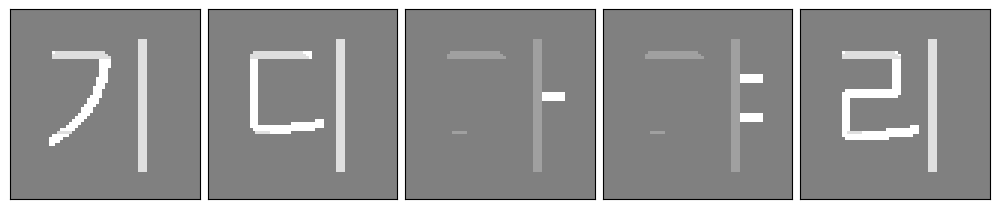

In [11]:
from sklearn.decomposition import NMF

print("=== Standard NMF Training (Baseline) ===")

# 1. Build & Run NMF Model
n_components = 5
model = NMF(n_components=n_components, init='nndsvda', random_state=0)

# Factorize: X ~ W1 * H1
# X was flattened in Appendix 1 (n_samples, n_features)
W1 = model.fit_transform(X.reshape(n_samples, -1)) 
H1 = model.components_ 

# 2. Visualize Basis Vectors
print("Visualizing Standard NMF Basis:")
# H1 needs reshaping to image dimensions for visualization
plot_gallery(H1.reshape(-1, *data_dims), n_row=1, n_col=5)

# 3. Quantitative Evaluation (IoU)
# Note: 'masks' and evaluation functions must be defined in Appendix 2
results_nmf, avg_iou_nmf = compute_jamo_iou(H1, ground_truth_masks)

print("\n=== Standard NMF Evaluation Results ===")
for jamo, info in results_nmf.items():
    print(f"Jamo {jamo}: IoU = {info['iou']:.4f} (Matched Basis #{info['basis_index']})")

print("-" * 30)
print(f"Average IoU (Standard NMF): {avg_iou_nmf:.4f}")